In [ ]:
import pandas as pd
from transformers import AutoTokenizer, AutoModelForMaskedLM
import torch


In [ ]:
from relevant_dicts import JP_MODIFIER_EXPLANATIONS,EN_MODIFIER_EXPLANATIONS
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
JP_MODIFIERS = list(JP_MODIFIER_EXPLANATIONS.keys())
EN_MODIFIERS = list(EN_MODIFIER_EXPLANATIONS.keys())
jp_tokenizer = AutoTokenizer.from_pretrained("cl-tohoku/bert-base-japanese")
jp_model = AutoModelForMaskedLM.from_pretrained("cl-tohoku/bert-base-japanese")
en_tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")
en_model = AutoModelForMaskedLM.from_pretrained("distilbert-base-uncased")

en_model.eval()
jp_model.eval()
en_model.to(device)
jp_model.to(device)
jp_cls_id = jp_tokenizer.cls_token_id
jp_sep_id = jp_tokenizer.sep_token_id
jp_mask_id = jp_tokenizer.mask_token_id
en_cls_id = en_tokenizer.cls_token_id
en_sep_id = en_tokenizer.sep_token_id
en_mask_id = en_tokenizer.mask_token_id
jp_sentence_templates = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_jp.csv",index_col=False)["Scenario Sentence"].values
en_sentence_templates = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_en.csv",index_col=False)["Scenario Sentence"].values


In [ ]:

def enumerate_wordpiece_segmentations(word, tokenizer, max_pieces=6):
    """
    DP over all ways to split `word` into vocab-valid WordPiece pieces.
    Returns a list of token-id lists (each a valid full segmentation of `word`).
    """
    n = len(word)
    # dp[i] = list of valid token-id sequences that cover word[:i]
    dp = [[] for _ in range(n + 1)]
    dp[0] = [[]]

    for i in range(n):
        if not dp[i]:
            continue
        for j in range(i + 1, n + 1):
            if j - i > 20:  # safety cap on piece length
                break
            piece = word[i:j]
            candidate = piece if i == 0 else "##" + piece
            tok_id = tokenizer.vocab.get(candidate) if hasattr(tokenizer, "vocab") else None
            if tok_id is None:
                tok_id = tokenizer.convert_tokens_to_ids(candidate)
                if tok_id == tokenizer.unk_token_id:
                    continue
            for prefix_seq in dp[i]:
                if len(prefix_seq) < max_pieces:
                    dp[j].append(prefix_seq + [tok_id])

    return dp[n]
import itertools

def enumerate_wordpiece_segmentations_multiword(phrase, tokenizer, max_pieces=6):
    """
    Handles multi-word phrases (e.g. 'a little') by splitting on whitespace
    first — WordPiece never lets a ## continuation piece cross a space — then
    enumerating segmentations per word and taking the cartesian product across
    words, concatenating ids in order.
    """
    words = phrase.split()
    if len(words) == 1:
        return enumerate_wordpiece_segmentations(phrase, tokenizer, max_pieces=max_pieces)

    per_word_segs = [enumerate_wordpiece_segmentations(w, tokenizer, max_pieces=max_pieces) for w in words]
    if any(not segs for segs in per_word_segs):
        return []  # one of the words itself has no valid segmentation

    combined = []
    for combo in itertools.product(*per_word_segs):
        merged = [tok_id for seg in combo for tok_id in seg]
        if len(merged) <= max_pieces * len(words):  # loosen cap proportionally for phrases
            combined.append(merged)
    return combined
def enumerate_variant_segmentations(candidate_str, tokenizer, max_pieces=6, sep="・"):
    """
    candidate_str may contain multiple orthographic variants of the same word,
    e.g. 'すこし・少し'. Splits on `sep`, enumerates valid WordPiece segmentations
    for each variant, and pools them into one deduplicated list — since they're
    just different spellings of the same underlying modifier, their probabilities
    all get marginalized together later.
    """
    variants = [v for v in candidate_str.split(sep) if v]  # drop empty strings from stray separators
    seen = set()
    segmentations = []

    for variant in variants:
        for seg in enumerate_wordpiece_segmentations_multiword(variant, tokenizer, max_pieces=max_pieces):
            key = tuple(seg)
            if key not in seen:
                seen.add(key)
                segmentations.append(seg)

    return segmentations

JP_MODIFIER_SEGMENTATIONS = {
    cand: enumerate_variant_segmentations(cand, jp_tokenizer, max_pieces=6)
    for cand in JP_MODIFIERS
}
EN_MODIFIER_SEGMENTATIONS = {# tokenizing canonically unlike in japanese because otherwise it blows up
    cand: [en_tokenizer.encode(cand, add_special_tokens=False)]  # single canonical segmentation, no enumeration
    for cand in EN_MODIFIERS
}
PLACEHOLDER = "__MOD__"


Create token dictionary

In [ ]:
LANG_CONFIG = {
    "en": (en_tokenizer, en_model, en_cls_id, en_sep_id, en_mask_id),
    "jp": (jp_tokenizer, jp_model, jp_cls_id, jp_sep_id, jp_mask_id),
}


def encode_template(sentence_template, lang="en"):
    """Tokenize prefix/suffix once per template, reused across all candidate words."""
    tokenizer = LANG_CONFIG[lang][0]
    idx = sentence_template.find(PLACEHOLDER)
    if idx == -1:
        raise ValueError(f"{PLACEHOLDER!r} not found in template")
    prefix = sentence_template[:idx]
    suffix = sentence_template[idx + len(PLACEHOLDER):]
    prefix_ids = tokenizer.encode(prefix, add_special_tokens=False)
    suffix_ids = tokenizer.encode(suffix, add_special_tokens=False)
    return prefix_ids, suffix_ids


def score_word_in_context(target_word, prefix_ids, suffix_ids, lang="en"):
    tokenizer, model, cls_id, sep_id, mask_id = LANG_CONFIG[lang]
    prefix_len = len(prefix_ids)

    target_ids_list = JP_MODIFIER_SEGMENTATIONS.get(target_word) or EN_MODIFIER_SEGMENTATIONS.get(target_word)
    if not target_ids_list:
        raise ValueError(f"No segmentation found for {target_word!r}")

    variant_log_sums = []
    with torch.inference_mode():
        for word_ids_full in target_ids_list:
            k = len(word_ids_full)

            # Build all k masked-reveal rows at once instead of looping forward passes
            rows = [
                [cls_id] + prefix_ids + word_ids_full[:i] + [mask_id] * (k - i) + suffix_ids + [sep_id]
                for i in range(k)
            ]
            input_ids = torch.tensor(rows, device=device)          # shape: (k, seq_len)

            logits = model(input_ids).logits                       # (k, seq_len, vocab)

            row_idx = torch.arange(k, device=device)
            target_positions = prefix_len + 1 + row_idx             # each row's own mask position
            target_logits = logits[row_idx, target_positions]       # (k, vocab)
            log_probs = torch.log_softmax(target_logits, dim=-1)    # (k, vocab)

            true_ids = torch.tensor(word_ids_full, device=device)
            log_prob_sum = log_probs[row_idx, true_ids].sum().item()

            variant_log_sums.append(log_prob_sum)

    # marginalize across segmentation variants (sum in probability space)
    return torch.logsumexp(torch.tensor(variant_log_sums), dim=0).item()


def get_candidate_scores(sentence_template, candidates, lang="en"):
    prefix_ids, suffix_ids = encode_template(sentence_template, lang)
    scores = {}
    for word in candidates:
        scores[word] = score_word_in_context(word, prefix_ids, suffix_ids, lang=lang)
    return scores

In [ ]:
for lang in ["en", "jp"]:
    results = {}  # {sentence_template: {candidate: score}}
    if lang == "en":
        sentence_templates = en_sentence_templates
        modifers = EN_MODIFIERS
    else:
        sentence_templates = jp_sentence_templates
        modifers = JP_MODIFIERS
    for sentence_template in sentence_templates:
        print("Sentence template:", sentence_template)
        results[sentence_template] = get_candidate_scores(sentence_template, modifers, lang=lang)
        print("Scores:", results[sentence_template])
    df = pd.DataFrame(results)          # columns = sentence templates, index = candidates
    df.index.name = "candidate"

    df.to_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12" + lang + "Perturb_context_results.csv")



In [56]:
import pandas as pd
import numpy as np
from scipy.special import logsumexp

for lang in ["En", "Jp"]:
    path = f"/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12{lang}Perturb_context_results.csv"
    df = pd.read_csv(path)
    candidate_col = df["candidate"]
    score_cols = df.drop(columns="candidate")

    # log-softmax per template column: x - logsumexp(x), so exp() of each column sums to 1
    normalized = score_cols.apply(lambda col: col - logsumexp(col.values), axis=0)

    out = pd.concat([candidate_col, normalized], axis=1)
    out_path = f"/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12{lang}Perturb_context_results_normalized.csv"
    out.to_csv(out_path, index=False)
    print(f"[{lang}] saved -> {out_path}")

[En] saved -> /Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results_normalized.csv
[Jp] saved -> /Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12JpPerturb_context_results_normalized.csv


In [ ]:
import pandas as pd
EN_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_en.csv"
JP_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_jp.csv"

ATTITUDE_ORDER_EN = ["Apologetic/Polite", "Neutral", "Irritated", "Desperate/Urgent"]
ATTITUDE_ORDER_JP = pd.read_csv(JP_CSV_PATH)["Speaker's Attitude"].unique().tolist()  # dynamically get the order from the CSV
for lang in ["en", "jp"]:
    results = {}
    if lang == "en":
        df = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results_normalized.csv")
        meta = pd.read_csv(EN_CSV_PATH)
    else:
        df = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12JpPerturb_context_results_normalized.csv")
        meta = pd.read_csv(JP_CSV_PATH)
    # --- map each sentence template (column) to its Speaker's Attitude category ---
    sentence_templates = df.columns.values
    modifiers = df.candidate.values
    print("modifers",modifiers)
    template_to_attitude = dict(zip(meta["Scenario Sentence"], meta["Speaker's Attitude"]))
    missing = [t for t in df.columns if t not in template_to_attitude]
    if missing:
        print(f"[{lang}] WARNING: {len(missing)} of {len(df.columns)} templates have no matching metadata row "
              f"-- they'll be dropped from the aggregation. First: {missing[0][:80]}")

    attitude_series = pd.Series({t: template_to_attitude.get(t) for t in df.columns})

    # --- aggregate log-probs per candidate per attitude category ---
    # mean in log-space = log of the geometric mean of the underlying probabilities
    # across that category's 20 scenarios; simplest, most robust choice for comparing
    # relative shifts (an alternative would be softmax-normalizing per scenario first,
    # then averaging actual probabilities -- ask if you want that version instead)
    candidate_col = df["candidate"]
    score_cols = df.drop(columns="candidate")

    attitude_df = score_cols.T.groupby(attitude_series).mean().T
    attitude_df.insert(0, "candidate", candidate_col)
        #     attitude_df = attitude_df.reindex(columns=[a for a in ATTITUDE_ORDER_EN if a in attitude_df.columns])
    # else:
    #     attitude_df = attitude_df.reindex(columns=[a for a in ATTITUDE_ORDER_JP if a in attitude_df.columns])

    print(f"\n[{lang}] mean log-prob by attitude category:\n", attitude_df, "\n")

    out_path = f"/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12{lang}_attitude_aggregated.csv"
    attitude_df.to_csv(out_path,index=False)
    print(f"[{lang}] saved -> {out_path}")

    # --- which modifiers swing the most across attitude categories? ---
    # attitude_range = (attitude_df.max(axis=1) - attitude_df.min(axis=1)).sort_values(ascending=False)
    print(f"[{lang}] modifiers with the largest swing across attitude categories:\n", attitude_range.head(10), "\n")

modifers ['a little' 'a bit' 'a hair' 'a smidge' 'a smidgen' 'a tad' 'a touch'
 'a whisker' 'kind of' 'kinda' 'sort of' 'sorta' 'somewhat' 'rather'
 'pretty' 'quite' 'relatively' 'comparatively' 'moderately' 'reasonably'
 'really' 'very' 'extremely' 'absolutely' 'achingly' 'adequately'
 'all but' 'almost' 'nearly' 'practically' 'virtually' 'just about'
 'appreciably' 'astonishingly' 'astoundingly' 'staggeringly'
 'phenomenally' 'spectacularly' 'stunningly' 'breathtakingly' 'at all'
 'awfully' 'barely' 'hardly' 'scarcely' 'basically' 'blindingly' 'bloody'
 'damn' 'freaking' 'fricking' 'effing' 'goddamn' 'closely' 'considerably'
 'crazy' 'crazily' 'insanely' 'ridiculously' 'stupidly' 'stupid' 'sick'
 'dead' 'deathly' 'directly' 'downright' 'enormously' 'enough'
 'completely' 'entirely' 'fully' 'totally' 'utterly' 'wholly' 'especially'
 'essentially' 'exceptionally' 'excessively' 'exclusively'
 'extraordinarily' 'faintly' 'fundamentally' 'further' 'genuinely'
 'greatly' 'hella' 'mega' 'ul

[en] modifiers with the largest swing across attitude categories:
 candidate
rather        2.389955
somewhat      2.101666
hella         2.022282
greatly       1.945243
blindingly    1.845815
goddamn       1.843310
positively    1.842431
kind of       1.830979
remarkably    1.789780
freaking      1.770703
dtype: float64 

candidate
too           5.794669
really        5.674895
pretty        5.293335
so            5.149176
very          4.816908
rather        4.110090
quite         4.061770
extremely     3.854832
kinda         3.438696
incredibly    3.374229
Name: Apologetic/Polite, dtype: float64
candidate
really        6.352331
too           5.821990
pretty        5.579762
very          5.445679
so            5.373200
extremely     4.403076
incredibly    3.961991
kinda         3.827336
quite         3.780384
damn          3.328696
Name: Neutral, dtype: float64
candidate
too           6.020328
really        5.916101
so            5.870059
pretty        4.490777
very          4.174596
d

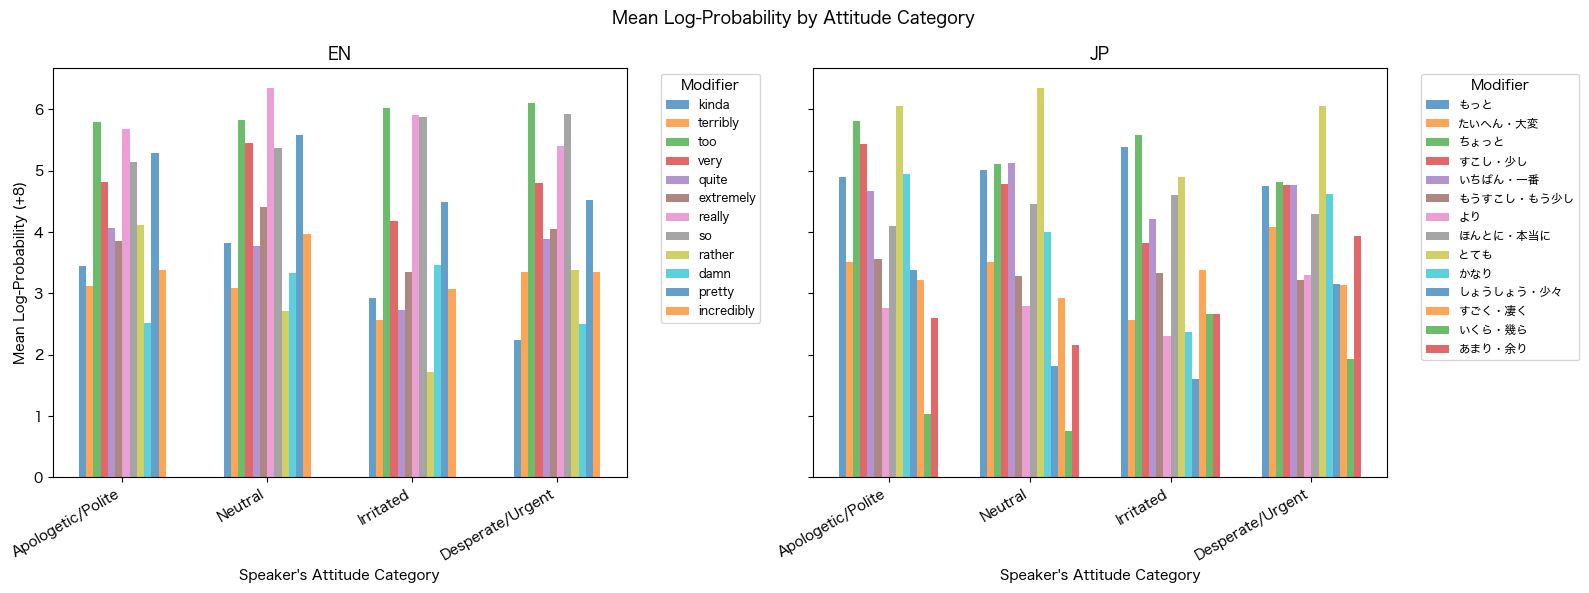


[en] mean log-prob by attitude category (with mean column):
         candidate  Apologetic/Polite   Neutral  Irritated  Desperate/Urgent  \
0        a little           0.846244  1.464570   1.266469          0.697129   
1           a bit           1.964082  1.837815   1.665309          2.057319   
2          a hair         -10.469415 -8.884578 -10.074923        -10.359386   
3        a smidge          -8.847961 -8.671926  -8.533496         -8.710021   
4       a smidgen          -7.632460 -7.548233  -7.556988         -7.762161   
..            ...                ...       ...        ...               ...   
152          well          -2.446523 -2.193082  -2.757770         -2.153434   
153  a little bit          -0.643013 -0.228942  -1.294439         -0.977083   
154   frightfully          -3.032619 -1.546751  -2.439640         -2.588814   
155          real           1.188942  1.980617   1.729566          0.871017   
156  indefinitely          -3.423912 -3.686025  -3.698043         -3.

/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/3632209809.py:139: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/3632209809.py:139: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


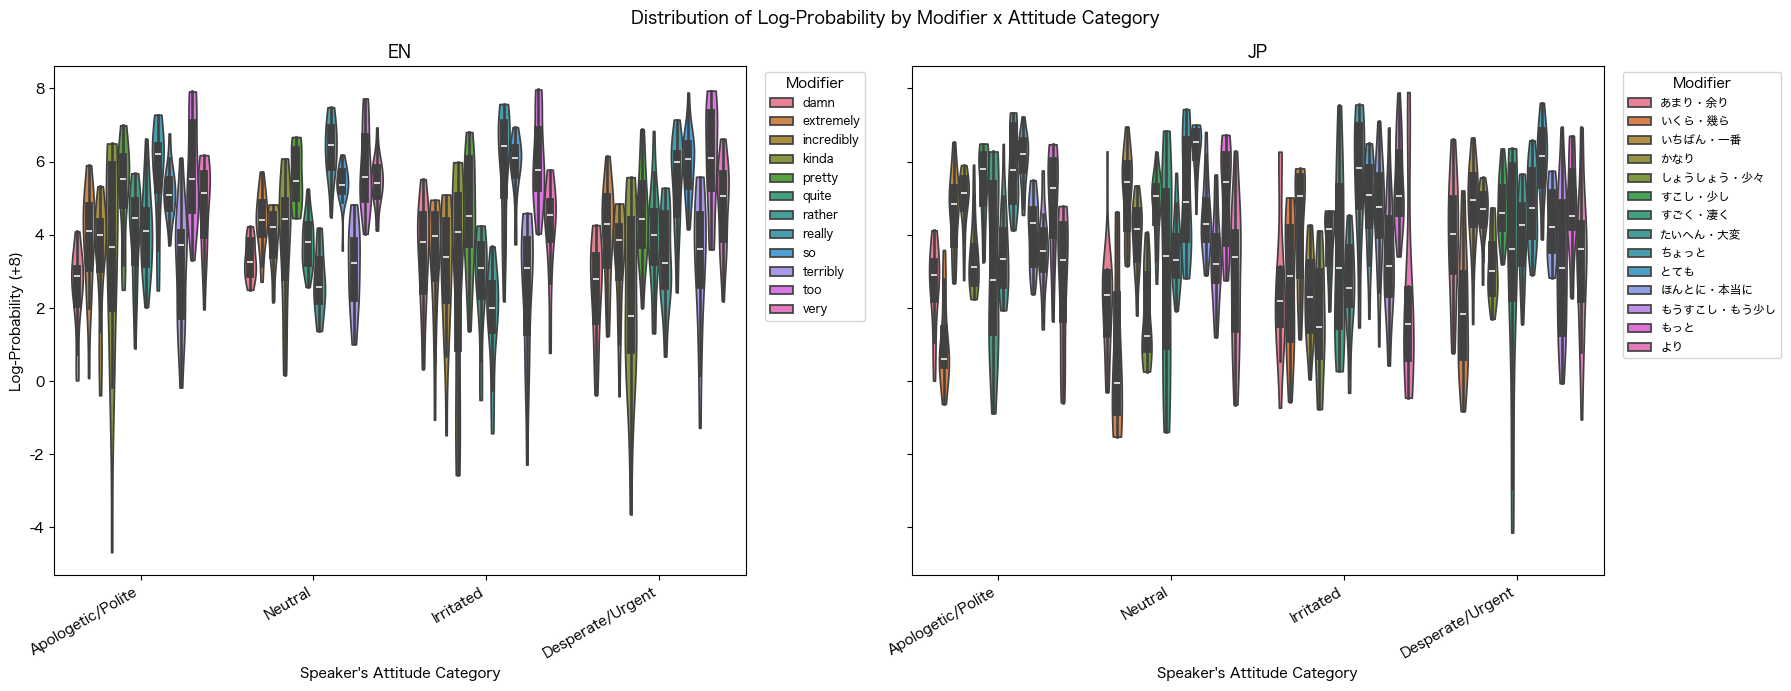

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)

plt.rcParams["font.family"] = font_prop.get_name()

# Map Japanese attitude labels onto their English equivalents so both
# panels share the same category names and ordering.
JP_TO_EN_ATTITUDE = {
    "恐縮・丁寧": "Apologetic/Polite",
    "ニュートラル": "Neutral",
    "イライラ": "Irritated",
    "困り果てる・切実": "Desperate/Urgent",
}
COMMON_ORDER = ["Apologetic/Polite", "Neutral", "Irritated", "Desperate/Urgent"]

OFFSET = 8  # shift values up so large negative log-probs are easier to read
TOP_N = 10  # for violin plots, restrict to the top-N modifiers per attitude category    
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

for ax, lang in zip(axes, ["en", "jp"]):
    attitude_df = pd.read_csv(
        f"/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12{lang}_attitude_aggregated.csv",
        index_col=0,
    )

    # Align Japanese column names/order with the English ones.
    if lang == "jp":
        attitude_df = attitude_df.rename(columns=JP_TO_EN_ATTITUDE)
    attitude_df = attitude_df[COMMON_ORDER]

    # Shift all values by a constant offset so the bars sit above 0.
    attitude_df = attitude_df + OFFSET

    # print average within-modifier variation across attitude categories
    attitude_range = (attitude_df.max(axis=1) - attitude_df.min(axis=1)).sort_values(ascending=False)
    print(f"[{lang}] modifiers with the largest swing across attitude categories:\n", attitude_range.head(10), "\n")

    categories = attitude_df.columns
    bar_width = 0.05

    # keep rows which are in top10 for at least one category
    top10_indices = set()
    for category in categories:
        print(attitude_df[category].nlargest(10))
        top10_indices.update(attitude_df[category].nlargest(10).index)
    attitude_df = attitude_df.loc[list(top10_indices)]
    n_modifiers = len(attitude_df)

    # plot all four categories for each modifier next to each other
    for i, (index, row) in enumerate(attitude_df.iterrows()):
        x_positions = [x + i * bar_width for x in range(len(row))]
        ax.bar(x_positions, row.values, width=bar_width, label=index, alpha=0.7)

    ax.set_xticks([x + (n_modifiers - 1) * bar_width / 2 for x in range(len(categories))])
    ax.set_xticklabels(categories, rotation=30, ha="right")
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.legend(title="Modifier", bbox_to_anchor=(1.05, 1), loc="upper left", fontsize="small")

axes[0].set_ylabel(f"Mean Log-Probability (+{OFFSET})")
fig.suptitle("Mean Log-Probability by Attitude Category")
plt.tight_layout()
plt.show()

long_dfs = {}
top_candidates_by_lang = {}

for lang in ["en", "jp"]:
    if lang == "en":
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(EN_CSV_PATH)
    else:
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12JpPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(JP_CSV_PATH)

    candidate_col = df["candidate"]
    score_cols = df.drop(columns="candidate")

    # --- map each sentence template (column) to its Speaker's Attitude category ---
    template_to_attitude = dict(zip(meta["Scenario Sentence"], meta["Speaker's Attitude"]))
    missing = [t for t in score_cols.columns if t not in template_to_attitude]
    if missing:
        print(
            f"[{lang}] WARNING: {len(missing)} of {len(score_cols.columns)} templates have no matching metadata row "
            f"-- they'll be dropped from the aggregation. First: {missing[0][:80]}"
        )
    attitude_series = pd.Series({t: template_to_attitude.get(t) for t in score_cols.columns})

    # --- aggregated mean per candidate per attitude category (used only to pick the "top" modifiers) ---
    attitude_df = score_cols.T.groupby(attitude_series).mean().T
    if lang == "jp":
        attitude_df = attitude_df.rename(columns=JP_TO_EN_ATTITUDE)
    attitude_df = attitude_df[[c for c in COMMON_ORDER if c in attitude_df.columns]]
    attitude_df = attitude_df + OFFSET
    attitude_df.insert(0, "candidate", candidate_col)
    attitude_df["mean"] = attitude_df[COMMON_ORDER].mean(axis=1)

    print(f"\n[{lang}] mean log-prob by attitude category (with mean column):\n", attitude_df, "\n")

    attitude_range = (attitude_df[COMMON_ORDER].max(axis=1) - attitude_df[COMMON_ORDER].min(axis=1)).rename("range")
    attitude_range.index = attitude_df["candidate"]
    print(f"[{lang}] modifiers with the largest swing across attitude categories:\n",
          attitude_range.sort_values(ascending=False).head(10), "\n")

    # union of the top-N modifiers (by mean log-prob) within each attitude category
    top_candidates = set()
    for category in COMMON_ORDER:
        top_candidates.update(attitude_df.nlargest(TOP_N, category)["candidate"])
    top_candidates_by_lang[lang] = sorted(top_candidates)

    # --- build the per-scenario (unaggregated) long-format table, restricted to those modifiers ---
    score_cols_offset = score_cols + OFFSET
    score_cols_offset.insert(0, "candidate", candidate_col)
    long_df = score_cols_offset.melt(id_vars="candidate", var_name="template", value_name="LogProb")
    long_df["Attitude"] = long_df["template"].map(template_to_attitude)
    if lang == "jp":
        long_df["Attitude"] = long_df["Attitude"].map(lambda a: JP_TO_EN_ATTITUDE.get(a, a))
    long_df = long_df.dropna(subset=["Attitude"])
    long_df = long_df[long_df["candidate"].isin(top_candidates)]

    long_dfs[lang] = long_df

# --- violin plots: distribution (not just mean) of per-scenario log-probs, one violin per modifier x category ---
fig, axes = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, lang in zip(axes, ["en", "jp"]):
    long_df = long_dfs[lang]
    hue_order = top_candidates_by_lang[lang]
    sns.violinplot(
        data=long_df,
        x="Attitude",
        y="LogProb",
        hue="candidate",
        order=COMMON_ORDER,
        hue_order=hue_order,
        cut=0,
        scale="width",
        dodge=True,
        ax=ax,
    )
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")
    ax.legend(title="Modifier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

axes[0].set_ylabel(f"Log-Probability (+{OFFSET})")
fig.suptitle("Distribution of Log-Probability by Modifier x Attitude Category")
plt.tight_layout()
plt.show()


[en] average within-scenario difference from Neutral, by attitude category:
 Attitude      Apologetic/Polite  Neutral     Irritated  Desperate/Urgent  \
candidate                                                                  
a bit              1.993937e-04      0.0  2.013970e-04      1.096401e-03   
a hair            -8.066771e-08      0.0 -8.280363e-08     -1.047188e-07   
a little          -9.966333e-04      0.0 -1.807660e-04     -1.111011e-03   
a little bit      -5.989306e-05      0.0 -1.453785e-04     -1.376040e-04   
a smidge           1.186112e-09      0.0  1.083060e-07      4.329869e-08   
...                         ...      ...           ...               ...   
way                2.961479e-05      0.0 -1.604126e-05     -4.720883e-05   
way too            8.071464e-04      0.0  4.702930e-04      1.349547e-03   
well               3.830719e-06      0.0 -1.799685e-05      5.785756e-05   
wholly            -1.135929e-06      0.0 -2.645591e-06     -6.299714e-06   
wicked    

/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/3687178693.py:189: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/3687178693.py:189: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


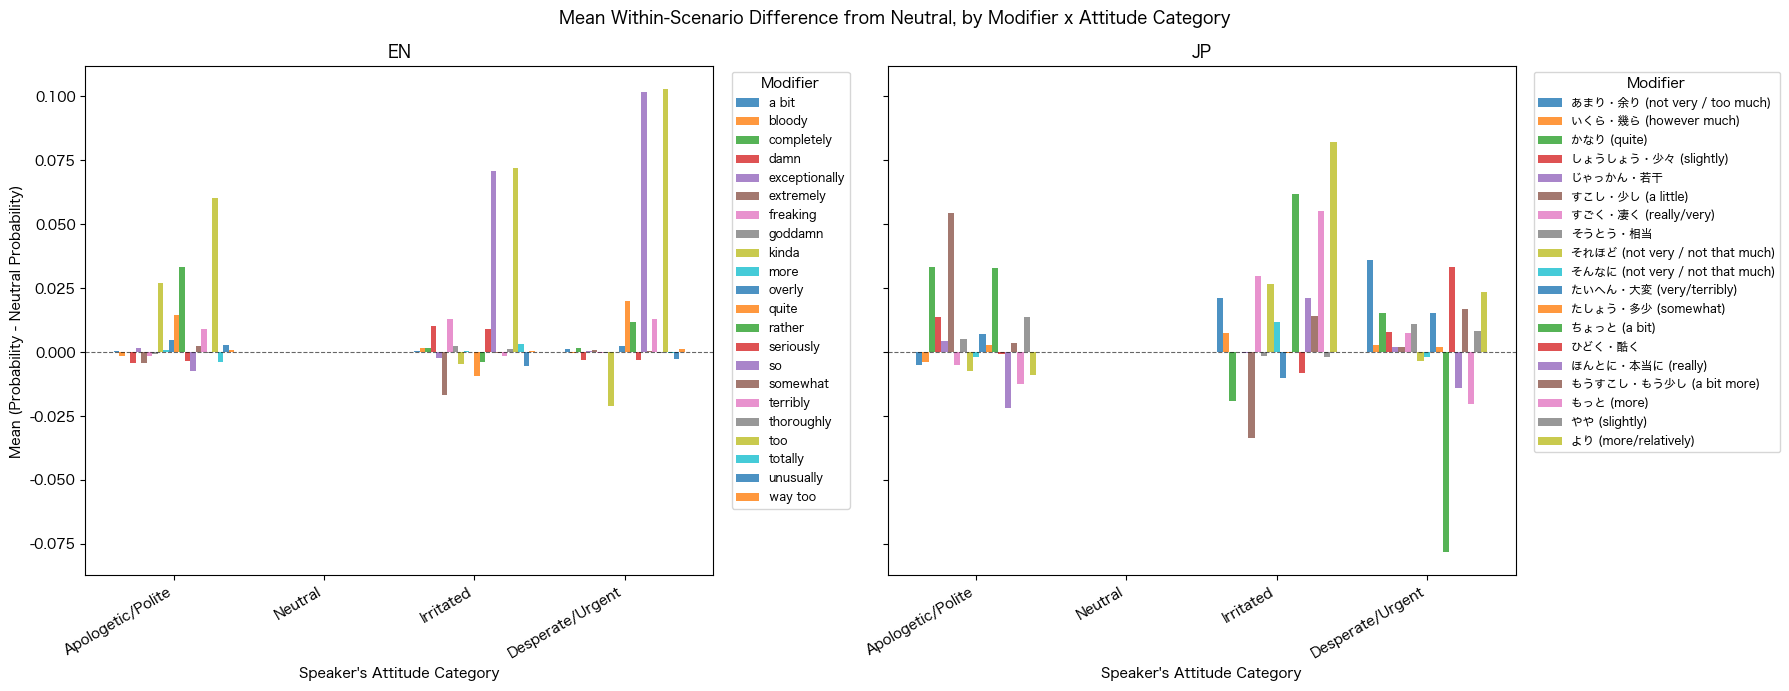

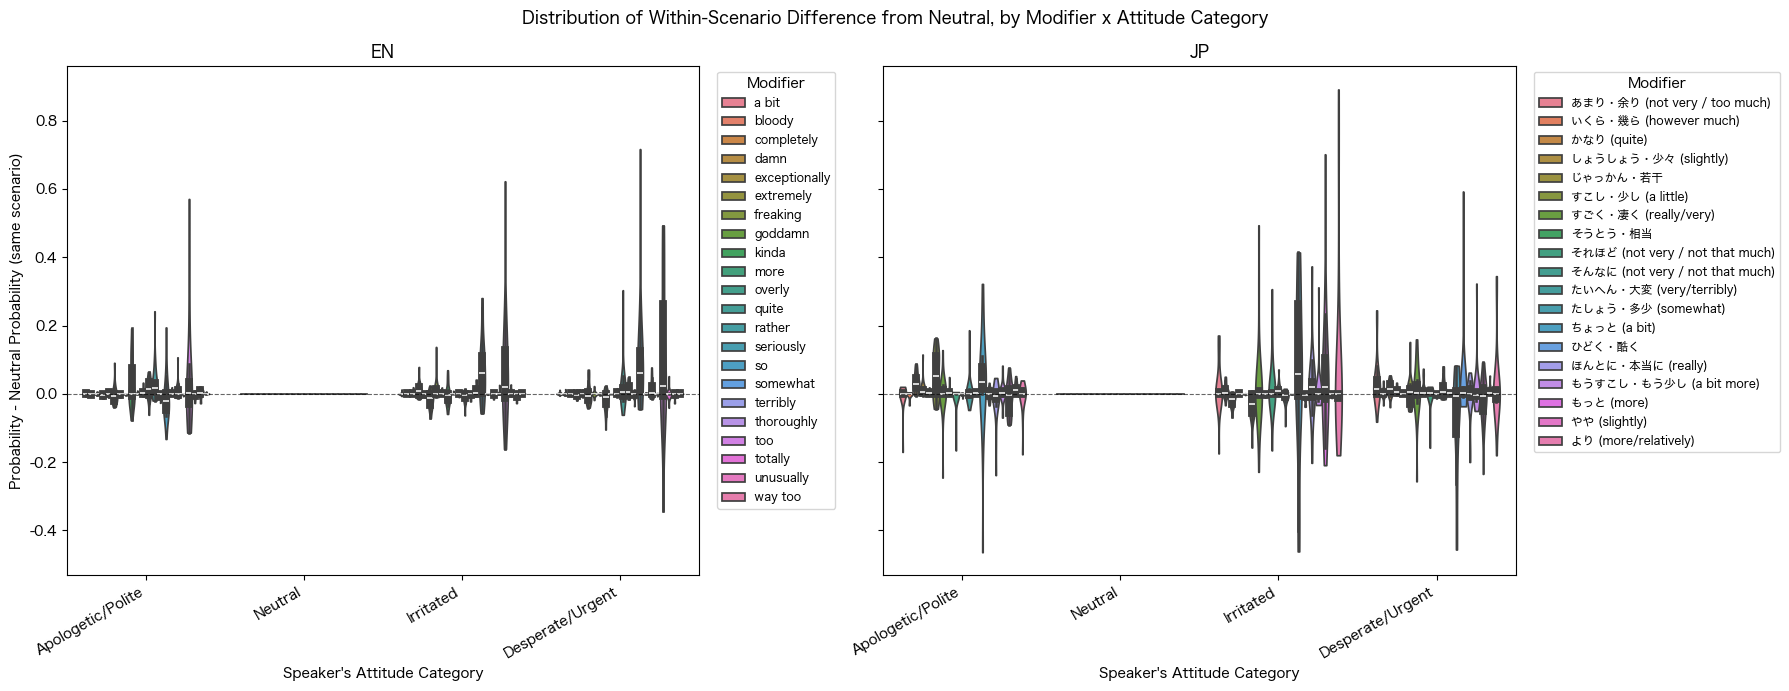

In [80]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

EN_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_en.csv"
JP_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_jp.csv"

# Map Japanese attitude labels onto their English equivalents so both
# panels share the same category names and ordering.
JP_TO_EN_ATTITUDE = {
    "恐縮・丁寧": "Apologetic/Polite",
    "ニュートラル": "Neutral",
    "イライラ": "Irritated",
    "困り果てる・切実": "Desperate/Urgent",
}
COMMON_ORDER = ["Apologetic/Polite", "Neutral", "Irritated", "Desperate/Urgent"]
NON_NEUTRAL = [c for c in COMMON_ORDER if c != "Neutral"]

# Rough English glosses for common Japanese degree modifiers, so the JP legend
# is readable to English speakers too. Looked up token-by-token (candidates are
# sometimes written as "reading・kanji" pairs, e.g. "たいへん・大変").
JP_MODIFIER_GLOSS = {
    "もっと": "more", "たいへん": "very/terribly", "大変": "very/terribly",
    "ちょっと": "a bit", "いちばん": "most", "一番": "most",
    "すこし": "a little", "少し": "a little",
    "もうすこし": "a bit more", "もう少し": "a bit more",
    "より": "more/relatively", "ほんとに": "really", "本当に": "really",
    "とても": "very", "かなり": "quite", "すごく": "really/very", "凄く": "really/very",
    "しょうしょう": "slightly", "少々": "slightly",
    "いくら": "however much", "幾ら": "however much",
    "あまり": "not very / too much", "余り": "not very / too much",
    "ものすごく": "extremely", "やたら": "unreasonably/excessively",
    "非常に": "extremely", "めちゃくちゃ": "extremely/insanely",
    "めっちゃ": "extremely (casual)", "ばか": "ridiculously", "馬鹿": "ridiculously",
    "随分": "quite a bit", "ずいぶん": "quite a bit", "だいぶ": "quite a bit", "大分": "quite a bit",
    "けっこう": "pretty/fairly", "結構": "pretty/fairly",
    "わりと": "relatively", "割と": "relatively",
    "はるかに": "far more", "極めて": "extremely", "きわめて": "extremely",
    "ちょい": "a bit (casual)", "多少": "somewhat",
    "それほど": "not very / not that much", "そんなに": "not very / not that much",
    "ひどく・酷く": "terribly", "そうとう・相当": "considerably", "やや": "slightly", "じゃっかん・若干": "slightly",
}


def gloss_candidate(candidate, lang):
    """Return 'candidate (English gloss)' for Japanese modifiers; candidate as-is for English."""
    if lang != "jp":
        return candidate
    parts = str(candidate).split("・")
    glosses = []
    for p in parts:
        g = JP_MODIFIER_GLOSS.get(p.strip())
        if g and g not in glosses:
            glosses.append(g)
    return f"{candidate} ({'/'.join(glosses)})" if glosses else candidate


TOP_N = 10  # how many modifiers per (non-neutral) category to pull into the "top" set

diff_long_dfs = {}
mean_diff_dfs = {}
var_diff_dfs = {}
top_candidates_by_lang = {}

for lang in ["en", "jp"]:
    if lang == "en":
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(EN_CSV_PATH)
    else:
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12JpPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(JP_CSV_PATH)

    candidate_col = df["candidate"]
    logprob_cols = df.drop(columns="candidate")

    # --- convert log-probabilities to normal (linear) probabilities ---
    prob_cols = np.exp(logprob_cols)

    # --- map each sentence template (column) to its scenario ID and its (English-aligned) attitude category ---
    template_to_id = dict(zip(meta["Scenario Sentence"], meta["ID"]))
    raw_attitude = dict(zip(meta["Scenario Sentence"], meta["Speaker's Attitude"]))
    template_to_attitude = {
        t: (JP_TO_EN_ATTITUDE.get(a, a) if lang == "jp" else a) for t, a in raw_attitude.items()
    }

    missing = [t for t in prob_cols.columns if t not in template_to_id]
    if missing:
        print(
            f"[{lang}] WARNING: {len(missing)} of {len(prob_cols.columns)} templates have no matching metadata row "
            f"-- they'll be dropped. First: {missing[0][:80]}"
        )

    # --- long format: candidate x template -> probability, with ID + Attitude attached ---
    prob_cols_with_candidate = prob_cols.copy()
    prob_cols_with_candidate.insert(0, "candidate", candidate_col)
    long_raw = prob_cols_with_candidate.melt(id_vars="candidate", var_name="template", value_name="Probability")
    long_raw["ID"] = long_raw["template"].map(template_to_id)
    long_raw["Attitude"] = long_raw["template"].map(template_to_attitude)
    long_raw = long_raw.dropna(subset=["ID", "Attitude"])

    # --- pivot to candidate x ID rows, one column per attitude category ---
    wide = long_raw.pivot_table(index=["candidate", "ID"], columns="Attitude", values="Probability")
    wide = wide.reindex(columns=COMMON_ORDER)

    # --- within-scenario difference: category probability minus that scenario's Neutral probability ---
    diff_wide = wide.subtract(wide["Neutral"], axis=0)
    diff_wide = diff_wide.reset_index()

    diff_long = diff_wide.melt(id_vars=["candidate", "ID"], value_vars=COMMON_ORDER,
                                var_name="Attitude", value_name="Diff")

    # --- average and variance of the within-scenario differences, per candidate x category ---
    mean_diff_df = diff_long.groupby(["candidate", "Attitude"])["Diff"].mean().unstack()[COMMON_ORDER]
    var_diff_df = diff_long.groupby(["candidate", "Attitude"])["Diff"].var().unstack()[COMMON_ORDER]

    mean_diff_df["mean"] = mean_diff_df[NON_NEUTRAL].mean(axis=1)          # Neutral column is trivially 0
    var_diff_df["mean_variance"] = var_diff_df[NON_NEUTRAL].mean(axis=1)

    print(f"\n[{lang}] average within-scenario difference from Neutral, by attitude category:\n", mean_diff_df, "\n")
    print(f"[{lang}] variance of within-scenario difference from Neutral, by attitude category:\n", var_diff_df, "\n")

    diff_range = (mean_diff_df[NON_NEUTRAL].max(axis=1) - mean_diff_df[NON_NEUTRAL].min(axis=1)).sort_values(ascending=False)
    print(f"[{lang}] modifiers with the largest swing in mean difference across (non-neutral) attitude categories:\n",
          diff_range.head(10), "\n")

    # union of the top-N modifiers (by mean difference) within each non-neutral category
    top_candidates = set()
    for category in NON_NEUTRAL:
        top_candidates.update(mean_diff_df[category].nlargest(TOP_N).index)
    top_candidates_by_lang[lang] = sorted(top_candidates)

    diff_long_dfs[lang] = diff_long[diff_long["candidate"].isin(top_candidates)]
    mean_diff_dfs[lang] = mean_diff_df.loc[top_candidates_by_lang[lang]]
    var_diff_dfs[lang] = var_diff_df.loc[top_candidates_by_lang[lang]]

# --- plot 1: bar plot of the MEAN within-scenario difference from Neutral, with error bars showing
# the standard deviation (sqrt of the variance) across scenarios -- one grouped bar per modifier x category ---
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, lang in zip(axes_bar, ["en", "jp"]):
    mean_diff_df = mean_diff_dfs[lang]
    var_diff_df = var_diff_dfs[lang]
    hue_order = top_candidates_by_lang[lang]
    n_modifiers = len(hue_order)
    bar_width = 0.8 / max(n_modifiers, 1)

    for i, candidate in enumerate(hue_order):
        row = mean_diff_df.loc[candidate, COMMON_ORDER]
        std = np.sqrt(var_diff_df.loc[candidate, COMMON_ORDER].clip(lower=0))
        x_positions = [x + i * bar_width for x in range(len(COMMON_ORDER))]
        ax.bar(
            x_positions,
            row.values,
            width=bar_width,
            capsize=2,
            error_kw={"elinewidth": 0.8, "alpha": 0.7},
            label=gloss_candidate(candidate, lang),
            alpha=0.8,
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_xticks([x + (n_modifiers - 1) * bar_width / 2 for x in range(len(COMMON_ORDER))])
    ax.set_xticklabels(COMMON_ORDER, rotation=30, ha="right")
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.legend(title="Modifier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

axes_bar[0].set_ylabel("Mean (Probability - Neutral Probability)")
fig_bar.suptitle("Mean Within-Scenario Difference from Neutral, by Modifier x Attitude Category")
fig_bar.tight_layout()

# --- plot 2: violin plot of the full DISTRIBUTION of within-scenario Neutral-subtracted differences ---
fig_violin, axes_violin = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, lang in zip(axes_violin, ["en", "jp"]):
    diff_long = diff_long_dfs[lang]
    hue_order = top_candidates_by_lang[lang]
    sns.violinplot(
        data=diff_long,
        x="Attitude",
        y="Diff",
        hue="candidate",
        order=COMMON_ORDER,
        hue_order=hue_order,
        cut=0,
        scale="width",
        dodge=True,
        ax=ax,
    )
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    handles, labels = ax.get_legend_handles_labels()
    labels = [gloss_candidate(l, lang) for l in labels]
    ax.legend(handles, labels, title="Modifier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

axes_violin[0].set_ylabel("Probability - Neutral Probability (same scenario)")
fig_violin.suptitle("Distribution of Within-Scenario Difference from Neutral, by Modifier x Attitude Category")
fig_violin.tight_layout()

plt.show()


[en] mean probability by attitude category (with overall mean column):
         candidate  Apologetic/Polite       Neutral     Irritated  \
0        a little       1.355648e-03  2.352281e-03  2.171515e-03   
1           a bit       3.416716e-03  3.217323e-03  3.418720e-03   
2          a hair       1.122522e-07  1.929199e-07  1.101162e-07   
3        a smidge       9.908138e-08  9.789526e-08  2.062013e-07   
4       a smidgen       3.455305e-07  3.520208e-07  5.143708e-07   
..            ...                ...           ...           ...   
152          well       6.867727e-05  6.484655e-05  4.684970e-05   
153  a little bit       3.123868e-04  3.722799e-04  2.269014e-04   
154   frightfully       2.406480e-05  1.201762e-04  8.399515e-05   
155          real       3.066562e-03  3.488257e-03  3.990676e-03   
156  indefinitely       4.114077e-05  5.193319e-05  2.814647e-05   

     Desperate/Urgent          mean  
0        1.241270e-03  1.780179e-03  
1        4.313723e-03  3.591620e-0

/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/4059507984.py:172: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/l5/1fqjsm5x4kl03ttg86km0mp40000gn/T/ipykernel_31772/4059507984.py:172: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(


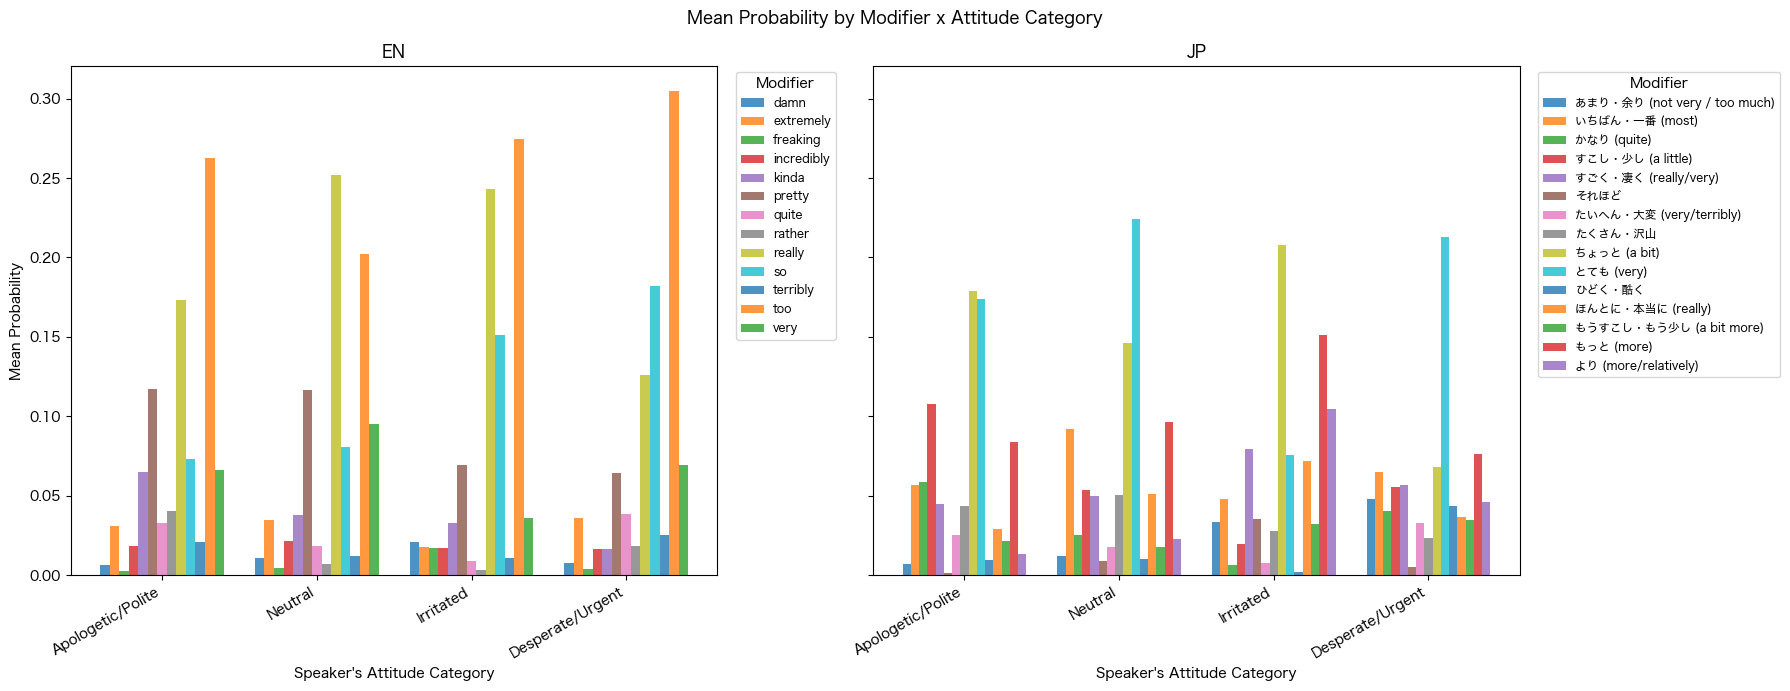

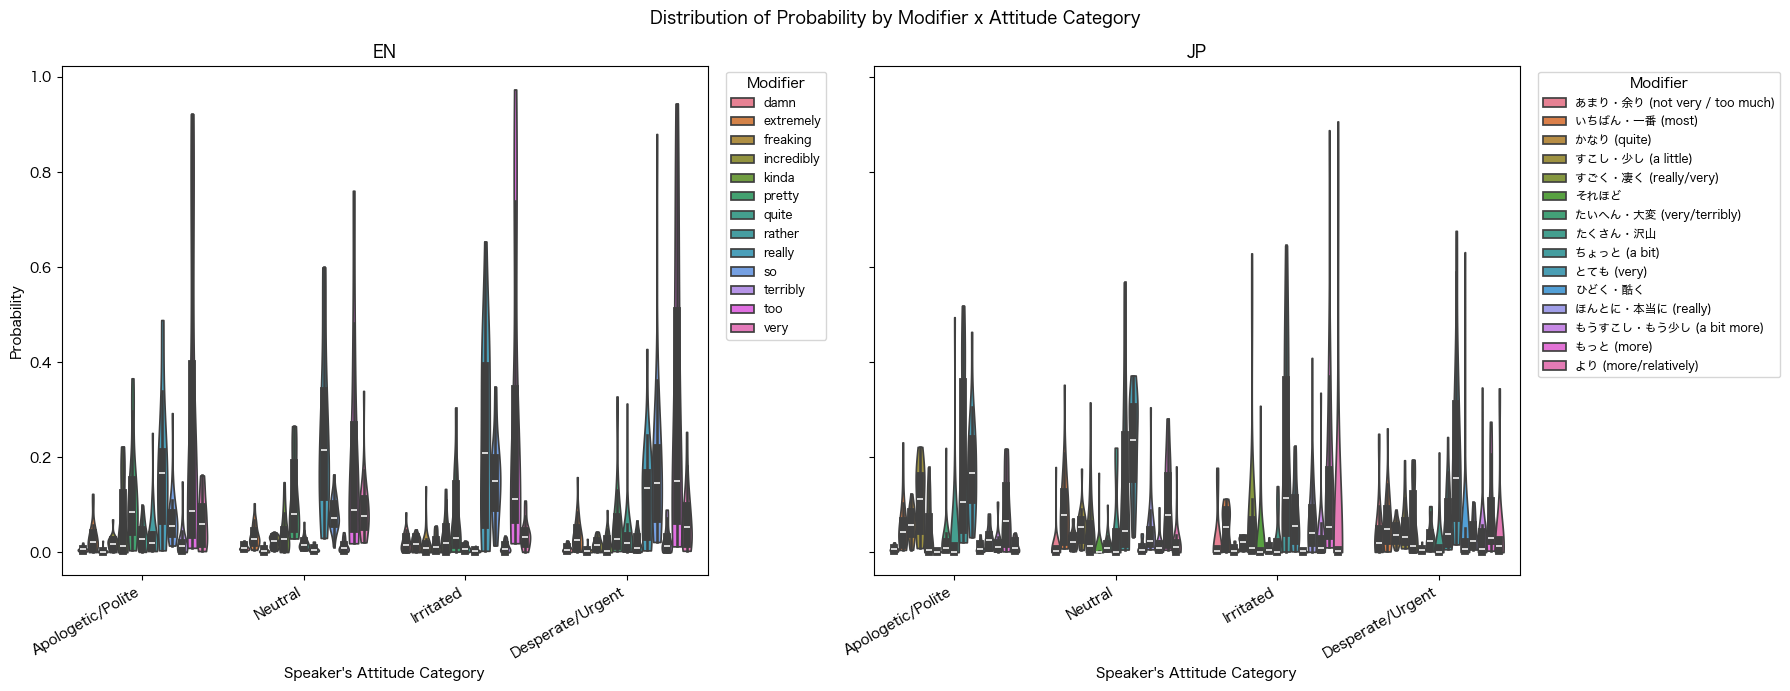

In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

font_path = "/System/Library/Fonts/ヒラギノ角ゴシック W3.ttc"
fm.fontManager.addfont(font_path)
font_prop = fm.FontProperties(fname=font_path)
plt.rcParams["font.family"] = font_prop.get_name()

EN_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_en.csv"
JP_CSV_PATH = "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/politeness_imposition_scenarios_jp.csv"

# Map Japanese attitude labels onto their English equivalents so both
# panels share the same category names and ordering.
JP_TO_EN_ATTITUDE = {
    "恐縮・丁寧": "Apologetic/Polite",
    "ニュートラル": "Neutral",
    "イライラ": "Irritated",
    "困り果てる・切実": "Desperate/Urgent",
}
COMMON_ORDER = ["Apologetic/Polite", "Neutral", "Irritated", "Desperate/Urgent"]

# Rough English glosses for common Japanese degree modifiers, so the JP legend
# is readable to English speakers too. Looked up token-by-token (candidates are
# sometimes written as "reading・kanji" pairs, e.g. "たいへん・大変").
JP_MODIFIER_GLOSS = {
    "もっと": "more", "たいへん": "very/terribly", "大変": "very/terribly",
    "ちょっと": "a bit", "いちばん": "most", "一番": "most",
    "すこし": "a little", "少し": "a little",
    "もうすこし": "a bit more", "もう少し": "a bit more",
    "より": "more/relatively", "ほんとに": "really", "本当に": "really",
    "とても": "very", "かなり": "quite", "すごく": "really/very", "凄く": "really/very",
    "しょうしょう": "slightly", "少々": "slightly",
    "いくら": "however much", "幾ら": "however much",
    "あまり": "not very / too much", "余り": "not very / too much",
    "ものすごく": "extremely", "やたら": "unreasonably/excessively",
    "非常に": "extremely", "めちゃくちゃ": "extremely/insanely",
    "めっちゃ": "extremely (casual)", "ばか": "ridiculously", "馬鹿": "ridiculously",
    "随分": "quite a bit", "ずいぶん": "quite a bit", "だいぶ": "quite a bit", "大分": "quite a bit",
    "けっこう": "pretty/fairly", "結構": "pretty/fairly",
    "わりと": "relatively", "割と": "relatively",
    "はるかに": "far more", "極めて": "extremely", "きわめて": "extremely",
    "ちょい": "a bit (casual)", "多少": "somewhat",
}


def gloss_candidate(candidate, lang):
    """Return 'candidate (English gloss)' for Japanese modifiers; candidate as-is for English."""
    if lang != "jp":
        return candidate
    parts = str(candidate).split("・")
    glosses = []
    for p in parts:
        g = JP_MODIFIER_GLOSS.get(p.strip())
        if g and g not in glosses:
            glosses.append(g)
    return f"{candidate} ({'/'.join(glosses)})" if glosses else candidate


TOP_N = 10  # how many modifiers per category to pull into the "top" set, same as the bar-plot version

long_dfs = {}
mean_dfs = {}
top_candidates_by_lang = {}

for lang in ["en", "jp"]:
    if lang == "en":
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(EN_CSV_PATH)
    else:
        df = pd.read_csv(
            "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12JpPerturb_context_results_normalized.csv"
        )
        meta = pd.read_csv(JP_CSV_PATH)

    candidate_col = df["candidate"]
    logprob_cols = df.drop(columns="candidate")

    # --- convert log-probabilities to normal (linear) probabilities ---
    prob_cols = np.exp(logprob_cols)

    # --- map each sentence template (column) to its Speaker's Attitude category ---
    template_to_attitude = dict(zip(meta["Scenario Sentence"], meta["Speaker's Attitude"]))
    missing = [t for t in prob_cols.columns if t not in template_to_attitude]
    if missing:
        print(
            f"[{lang}] WARNING: {len(missing)} of {len(prob_cols.columns)} templates have no matching metadata row "
            f"-- they'll be dropped from the aggregation. First: {missing[0][:80]}"
        )
    attitude_series = pd.Series({t: template_to_attitude.get(t) for t in prob_cols.columns})

    # --- 1. average probability per candidate per attitude category ---
    mean_df = prob_cols.T.groupby(attitude_series).mean().T
    mean_df = (
        mean_df.rename(columns=JP_TO_EN_ATTITUDE) if lang == "jp" else mean_df
    )
    mean_df = mean_df[[c for c in COMMON_ORDER if c in mean_df.columns]]
    mean_df.insert(0, "candidate", candidate_col)
    mean_df["mean"] = mean_df[COMMON_ORDER].mean(axis=1)

    print(f"\n[{lang}] mean probability by attitude category (with overall mean column):\n", mean_df, "\n")

    # --- 2. variance of probability per candidate per attitude category ---
    var_df = prob_cols.T.groupby(attitude_series).var().T
    var_df = (
        var_df.rename(columns=JP_TO_EN_ATTITUDE) if lang == "jp" else var_df
    )
    var_df = var_df[[c for c in COMMON_ORDER if c in var_df.columns]]
    var_df.insert(0, "candidate", candidate_col)
    var_df["mean_variance"] = var_df[COMMON_ORDER].mean(axis=1)

    print(f"[{lang}] variance of probability by attitude category (with overall mean-variance column):\n", var_df, "\n")

    prob_range = (mean_df[COMMON_ORDER].max(axis=1) - mean_df[COMMON_ORDER].min(axis=1)).rename("range")
    prob_range.index = mean_df["candidate"]
    print(f"[{lang}] modifiers with the largest swing in mean probability across attitude categories:\n",
          prob_range.sort_values(ascending=False).head(10), "\n")

    # union of the top-N modifiers (by mean probability) within each attitude category
    top_candidates = set()
    for category in COMMON_ORDER:
        top_candidates.update(mean_df.nlargest(TOP_N, category)["candidate"])
    top_candidates_by_lang[lang] = sorted(top_candidates)
    mean_dfs[lang] = mean_df[mean_df["candidate"].isin(top_candidates)]

    # --- build the per-scenario (unaggregated) long-format table of probabilities, restricted to those modifiers ---
    prob_cols_with_candidate = prob_cols.copy()
    prob_cols_with_candidate.insert(0, "candidate", candidate_col)
    long_df = prob_cols_with_candidate.melt(id_vars="candidate", var_name="template", value_name="Probability")
    long_df["Attitude"] = long_df["template"].map(template_to_attitude)
    if lang == "jp":
        long_df["Attitude"] = long_df["Attitude"].map(lambda a: JP_TO_EN_ATTITUDE.get(a, a))
    long_df = long_df.dropna(subset=["Attitude"])
    long_df = long_df[long_df["candidate"].isin(top_candidates)]

    long_dfs[lang] = long_df

# --- plot 1: bar plot of MEAN probability, one grouped bar per modifier x category ---
fig_bar, axes_bar = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, lang in zip(axes_bar, ["en", "jp"]):
    mean_df = mean_dfs[lang]
    hue_order = top_candidates_by_lang[lang]
    n_modifiers = len(hue_order)
    bar_width = 0.8 / max(n_modifiers, 1)

    for i, candidate in enumerate(hue_order):
        row = mean_df[mean_df["candidate"] == candidate][COMMON_ORDER].iloc[0]
        x_positions = [x + i * bar_width for x in range(len(COMMON_ORDER))]
        ax.bar(x_positions, row.values, width=bar_width, label=gloss_candidate(candidate, lang), alpha=0.8)

    ax.set_xticks([x + (n_modifiers - 1) * bar_width / 2 for x in range(len(COMMON_ORDER))])
    ax.set_xticklabels(COMMON_ORDER, rotation=30, ha="right")
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.legend(title="Modifier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

axes_bar[0].set_ylabel("Mean Probability")
fig_bar.suptitle("Mean Probability by Modifier x Attitude Category")
fig_bar.tight_layout()

# --- plot 2: violin plots of the full DISTRIBUTION of probabilities, one violin per modifier x category ---
fig_violin, axes_violin = plt.subplots(1, 2, figsize=(18, 7), sharey=True)

for ax, lang in zip(axes_violin, ["en", "jp"]):
    long_df = long_dfs[lang]
    hue_order = top_candidates_by_lang[lang]
    sns.violinplot(
        data=long_df,
        x="Attitude",
        y="Probability",
        hue="candidate",
        order=COMMON_ORDER,
        hue_order=hue_order,
        cut=0,
        scale="width",
        dodge=True,
        ax=ax,
    )
    ax.set_title(lang.upper())
    ax.set_xlabel("Speaker's Attitude Category")
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_ha("right")

    handles, labels = ax.get_legend_handles_labels()
    labels = [gloss_candidate(l, lang) for l in labels]
    ax.legend(handles, labels, title="Modifier", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize="small")

axes_violin[0].set_ylabel("Probability")
fig_violin.suptitle("Distribution of Probability by Modifier x Attitude Category")
fig_violin.tight_layout()

plt.show()

In [81]:
import numpy as np
import pandas as pd
from itertools import combinations
from scipy.spatial.distance import jensenshannon


def softmax_normalize_columns(df):
    """
    Converts each column's raw log-prob scores into a proper probability
    distribution over the candidate set (sums to 1 per column) via a
    numerically stable softmax. Interpretation: "given the answer is one of
    these N candidates, how likely is each one relative to the others."
    """
    shifted = df.subtract(df.max(axis=0), axis=1)  # stability: avoid overflow in exp()
    exp_df = np.exp(shifted)
    prob_df = exp_df.div(exp_df.sum(axis=0), axis=1)
    assert np.allclose(prob_df.sum(axis=0), 1.0), "Columns did not normalize to 1 -- check for NaNs in df"
    return prob_df


def distribution_distance_matrix(prob_df, metric="jensenshannon"):
    """
    Pairwise distance between each pair of sentence templates' (columns')
    probability distributions over modifiers.
    """
    templates = prob_df.columns.tolist()
    dist = pd.DataFrame(0.0, index=templates, columns=templates)

    for t1, t2 in combinations(templates, 2):
        p, q = prob_df[t1].values, prob_df[t2].values

        if metric == "jensenshannon":
            d = jensenshannon(p, q, base=2)          # true metric, bounded [0, 1]
        elif metric == "hellinger":
            d = np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))  # true metric, bounded [0, 1]
        elif metric == "total_variation":
            d = 0.5 * np.sum(np.abs(p - q))          # true metric, bounded [0, 1]
        else:
            raise ValueError(f"Unknown metric: {metric}")

        dist.loc[t1, t2] = d
        dist.loc[t2, t1] = d

    return dist


def kl_divergence_matrix(prob_df):
    """
    KL divergence is NOT symmetric (D_KL(P||Q) != D_KL(Q||P)) and not a true
    metric -- kept separate so you don't accidentally treat it as one.
    Rows = P, columns = Q: entry [i, j] = D_KL(template_i || template_j).
    """
    templates = prob_df.columns.tolist()
    eps = 1e-12
    kl = pd.DataFrame(0.0, index=templates, columns=templates)
    for t1 in templates:
        for t2 in templates:
            if t1 == t2:
                continue
            p, q = prob_df[t1].values, prob_df[t2].values
            kl.loc[t1, t2] = np.sum(p * np.log2((p + eps) / (q + eps)))
    return kl
# download Aug11perturb_context_results as jp_df
jp_df = pd.read_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug11perturb_context_results.csv", index_col=0)  # columns = sentence templates, index = candidates

# --- run it ---
prob_df = softmax_normalize_columns(df)

js_dist = distribution_distance_matrix(prob_df, metric="jensenshannon")
hellinger_dist = distribution_distance_matrix(prob_df, metric="hellinger")
tv_dist = distribution_distance_matrix(prob_df, metric="total_variation")

print("Jensen-Shannon distance:\n", js_dist, "\n")
print("Hellinger distance:\n", hellinger_dist, "\n")
print("Total variation distance:\n", tv_dist, "\n")

print("\n\nNow running on Japanese data...\n")
df = jp_df 
df = df[(df > -8).any(axis=1)]
prob_df = softmax_normalize_columns(df)

js_dist = distribution_distance_matrix(prob_df, metric="jensenshannon")
hellinger_dist = distribution_distance_matrix(prob_df, metric="hellinger")
tv_dist = distribution_distance_matrix(prob_df, metric="total_variation")

print("Jensen-Shannon distance:\n", js_dist, "\n")
print("Hellinger distance:\n", hellinger_dist, "\n")
print("Total variation distance:\n", tv_dist, "\n")

TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [ ]:
def combined_square_distance_table(prob_df, metrics=("jensenshannon", "hellinger", "total_variation")):
    """
    One context x context table where each cell holds all requested metrics
    together, e.g. 'JS=0.121 | Hel=0.154 | TV=0.183', instead of printing a
    separate full square matrix per metric.
    """
    templates = prob_df.columns.tolist()
    table = pd.DataFrame("", index=templates, columns=templates)

    metric_fns = {
        "jensenshannon": lambda p, q: jensenshannon(p, q, base=2),
        "hellinger": lambda p, q: np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)),
        "total_variation": lambda p, q: 0.5 * np.sum(np.abs(p - q)),
    }
    labels = {"jensenshannon": "JS", "hellinger": "Hel", "total_variation": "TV"}

    for t in templates:
        table.loc[t, t] = " | ".join(f"{labels[m]}=0.000" for m in metrics)

    for t1, t2 in combinations(templates, 2):
        p, q = prob_df[t1].values, prob_df[t2].values
        cell = " | ".join(f"{labels[m]}={metric_fns[m](p, q):.3f}" for m in metrics)
        table.loc[t1, t2] = cell
        table.loc[t2, t1] = cell

    return table


# --- English ---
en_df = pd.read_csv(
    "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug12EnPerturb_context_results.csv",
    index_col=0,
)
df = en_df
prob_df = softmax_normalize_columns(df)
en_table = combined_square_distance_table(prob_df)
print("English context x context:\n", en_table, "\n")

# --- Japanese ---
jp_df = pd.read_csv(
    "/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/Aug11perturb_context_results.csv",
    index_col=0,
)
df = jp_df
df = df[(df > -8).any(axis=1)]
prob_df = softmax_normalize_columns(df)
jp_table = combined_square_distance_table(prob_df)
print("\nJapanese context x context:\n", jp_table)

In [ ]:
from itertools import combinations
import numpy as np
import pandas as pd
from scipy.spatial.distance import jensenshannon

def combined_distance_table(prob_df):
    """One row per pair of templates, one column per metric -- easier to scan
    than three separate NxN matrices."""
    templates = prob_df.columns.tolist()
    rows = []
    for t1, t2 in combinations(templates, 2):
        p, q = prob_df[t1].values, prob_df[t2].values
        rows.append({
            "template_1": t1,
            "template_2": t2,
            "jensenshannon": jensenshannon(p, q, base=2),
            "hellinger": np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2)),
            "total_variation": 0.5 * np.sum(np.abs(p - q)),
        })
    return pd.DataFrame(rows)


df = jp_df
df = df[(df > -8).any(axis=1)]
prob_df = softmax_normalize_columns(df)

dist_table = combined_distance_table(prob_df)
# pd.set_option("display.max_colwidth", None)  # don't truncate long template strings
print(dist_table.to_string(index=False))

visualize and save plots

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.heatmap(df, center=0)
plt.title("Candidate Scores for Each Sentence Template")
plt.xlabel("Sentence Template")
plt.ylabel("Candidate")
plt.show()
df.to_csv("/Users/norikomachino/Documents/YukaWork/comparingCulturesPolitenessLLM/finalized_pipeline/data/enAug11perturb_context_results.csv")


In [ ]:
import numpy as np

# two distributions differing mainly in a "long tail" of rare candidates
p = np.array([0.30, 0.30, 0.15, 0.03, 0.01, 0.03])
q = np.array([0.50, 0.30, 0.15, 0.01, 0.01, 0.03])  # swapped two rare probabilities

def kl(p, q, eps=1e-12):
    return np.sum(p * np.log2((p + eps) / (q + eps)))

def js(p, q, eps=1e-12):
    m = 0.5 * (p + q)
    return 0.5 * kl(p, m, eps) + 0.5 * kl(q, m, eps)

def hellinger(p, q):
    return np.sqrt(0.5 * np.sum((np.sqrt(p) - np.sqrt(q)) ** 2))

def total_variation(p, q):
    return 0.5 * np.sum(np.abs(p - q))

print("KL(p||q):          ", kl(p, q))
print("JS distance:        ", np.sqrt(js(p, q)))
print("Hellinger distance: ", hellinger(p, q))
print("Total variation:     ", total_variation(p, q))